<a href="https://colab.research.google.com/github/likith2109/demo-repo/blob/main/p1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
pip install pennylane qiskit qiskit-machine-learning torch torchvision scikit-learn pandas numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 810.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 94.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 60.0 MB/s eta 0:00:00
  Attempting uninstall: autograd
    Found existing installation: autograd 1.9.1
    Uninstalling autograd-1.9.1:
      Successfully 

The 'Heart Disease Dataset.csv' file has been successfully uploaded to the `/content/` directory. Now, let's load the data using pandas.

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Heart Disease Dataset.csv')

# Display the first 5 rows
display(df.head())

,Age,Cholesterol,Maximum Heart Rate,Resting Blood Pressure,HeartDisease
0,54,206,108,110,0
1,51,227,154,94,1
2,63,187,144,140,0
3,42,209,173,120,1
4,44,226,169,120,1


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Heart Disease Dataset.csv')

# Display the first 5 rows
display(df.head())

,Age,Cholesterol,Maximum Heart Rate,Resting Blood Pressure,HeartDisease
0,54,206,108,110,0
1,51,227,154,94,1
2,63,187,144,140,0
3,42,209,173,120,1
4,44,226,169,120,1


# New section

In [8]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC

# PyTorch & PennyLane
import torch
import torch.nn as nn
import torch.optim as optim
import pennylane as qml

# Qiskit for QSVM
from qiskit.circuit.library import PauliFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel

In [9]:
def load_and_preprocess_data():
    # Load dataset
    df = pd.read_csv("Heart Disease Dataset.csv")

    # Select the 4 clinical features as specified
    features = ['Age', 'Cholesterol', 'Maximum Heart Rate', 'Resting Blood Pressure']
    X = df[features].values

    # Target column verified as 'HeartDisease'
    y = df['HeartDisease'].values

    # Min-Max Scaling
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    # Angle Encoding mapping scales features to [0, pi]
    X_scaled = X_scaled * np.pi

    # Split the data (80% training, 20% testing)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = load_and_preprocess_data()
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

Training samples: 262, Testing samples: 66


In [10]:
n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    # Explicitly handle batching by iterating if necessary,
    # though PennyLane usually handles RX broadcasting.
    for i in range(n_qubits):
        qml.RX(inputs[..., i], wires=i)

    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))

In [11]:
class VQC(nn.Module):
    def __init__(self, n_layers=2):
        super(VQC, self).__init__()
        weight_shapes = {"weights": (n_layers, n_qubits, 3)}
        self.qlayer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

    def forward(self, x):
        # Ensure the output has the shape (batch_size, 1)
        x = self.qlayer(x).reshape(-1, 1)
        return torch.sigmoid(x)

class HQNN(nn.Module):
    def __init__(self, n_layers=2):
        super(HQNN, self).__init__()
        self.fc1 = nn.Linear(4, 4)
        weight_shapes = {"weights": (n_layers, n_qubits, 3)}
        self.qlayer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)
        self.fc2 = nn.Linear(1, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        # Reshape to (batch_size, 1) before passing to the final linear layer
        x = self.qlayer(x).reshape(-1, 1)
        x = self.fc2(x)
        return torch.sigmoid(x)

In [12]:
def train_and_evaluate_torch_model(model, X_train, y_train, X_test, y_test, epochs=100):
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)

    criterion = nn.BCELoss()
    # Using Adam optimizer as required
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    start_time = time.time()

    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_train_t)
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()

    train_time = time.time() - start_time

    # Testing
    test_start_time = time.time()
    model.eval()
    with torch.no_grad():
        outputs = model(X_test_t) # Get raw probabilities
        preds = (outputs.numpy().flatten() > 0.5).astype(int) # Binary predictions
    test_time = time.time() - test_start_time

    metrics = {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1-Score": f1_score(y_test, preds, zero_division=0),
        "Training Time (s)": train_time,
        "Testing Time (s)": test_time
    }
    # Return metrics, y_test, binary predictions, and probability scores
    return metrics, y_test, preds, outputs.numpy().flatten()

def run_qsvm(X_train, y_train, X_test, y_test):
    # Using PauliFeatureMap for Qiskit-based Quantum Kernel Evaluation
    feature_map = PauliFeatureMap(feature_dimension=4, reps=2, paulis=['Z'])
    qkernel = FidelityQuantumKernel(feature_map=feature_map)

    # Initialize traditional SVC using the quantum kernel
    # Set probability=True to enable predict_proba
    qsvm = SVC(kernel=qkernel.evaluate, probability=True)

    start_time = time.time()
    qsvm.fit(X_train, y_train)
    train_time = time.time() - start_time

    test_start_time = time.time()
    preds = qsvm.predict(X_test)
    # Get probability estimates for the positive class
    y_prob = qsvm.predict_proba(X_test)[:, 1]
    test_time = time.time() - test_start_time

    metrics = {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1-Score": f1_score(y_test, preds, zero_division=0),
        "Training Time (s)": train_time,
        "Testing Time (s)": test_time
    }
    # Return metrics, y_test, binary predictions, and probability scores
    return metrics, y_test, preds, y_prob


In [13]:
results = {}

# 1. Variational Quantum Classifier (VQC)
print("Training VQC...")
vqc_model = VQC(n_layers=2)
vqc_results, y_test_vqc, y_pred_vqc, y_prob_vqc = train_and_evaluate_torch_model(vqc_model, X_train, y_train, X_test, y_test)
results["VQC"] = vqc_results

# 2. Quantum Neural Network (QNN)
print("Training QNN...")
qnn_model = VQC(n_layers=3)
qnn_results, y_test_qnn, y_pred_qnn, y_prob_qnn = train_and_evaluate_torch_model(qnn_model, X_train, y_train, X_test, y_test)
results["QNN"] = qnn_results

# 3. Hybrid Quantum Neural Network (HQNN)
print("Training HQNN...")
hqnn_model = HQNN(n_layers=2)
hqnn_results, y_test_hqnn, y_pred_hqnn, y_prob_hqnn = train_and_evaluate_torch_model(hqnn_model, X_train, y_train, X_test, y_test)
results["HQNN"] = hqnn_results

# 4. Quantum Support Vector Machine (QSVM)
print("Training QSVM (Qiskit)... (This may take a few minutes)")
qsvm_results, y_test_qsvm, y_pred_qsvm, y_prob_qsvm = run_qsvm(X_train, y_train, X_test, y_test)
results["QSVM"] = qsvm_results

# Store prediction data for later use (assuming y_test is the same for all)
predictions_data = {
    'y_test': y_test, # y_test is the same for all models as it's from the split
    'VQC': {'y_pred': y_pred_vqc, 'y_prob': y_prob_vqc},
    'QNN': {'y_pred': y_pred_qnn, 'y_prob': y_prob_qnn},
    'HQNN': {'y_pred': y_pred_hqnn, 'y_prob': y_prob_hqnn},
    'QSVM': {'y_pred': y_pred_qsvm, 'y_prob': y_prob_qsvm}
}

# Print Results Comparison Table
print("\n" + "="*80)
print("PERFORMANCE EVALUATION METRICS COMPARISON")
print("="*80)
df_results = pd.DataFrame(results).T
print(df_results.to_string())
print("="*80)


Training VQC...
Training QNN...
Training HQNN...
Training QSVM (Qiskit)... (This may take a few minutes)


/tmp/ipykernel_448/1242105846.py:43: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation.pauli_feature_map.PauliFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the pauli_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = PauliFeatureMap(feature_dimension=4, reps=2, paulis=['Z'])



PERFORMANCE EVALUATION METRICS COMPARISON
      Accuracy  Precision    Recall  F1-Score  Training Time (s)  Testing Time (s)
VQC   0.712121   0.666667  0.689655  0.677966           1.588943          0.007271
QNN   0.742424   0.687500  0.758621  0.721311           1.936680          0.009012
HQNN  0.712121   0.678571  0.655172  0.666667           2.164706          0.007416
QSVM  0.636364   0.586207  0.586207  0.586207         124.666825        120.552958


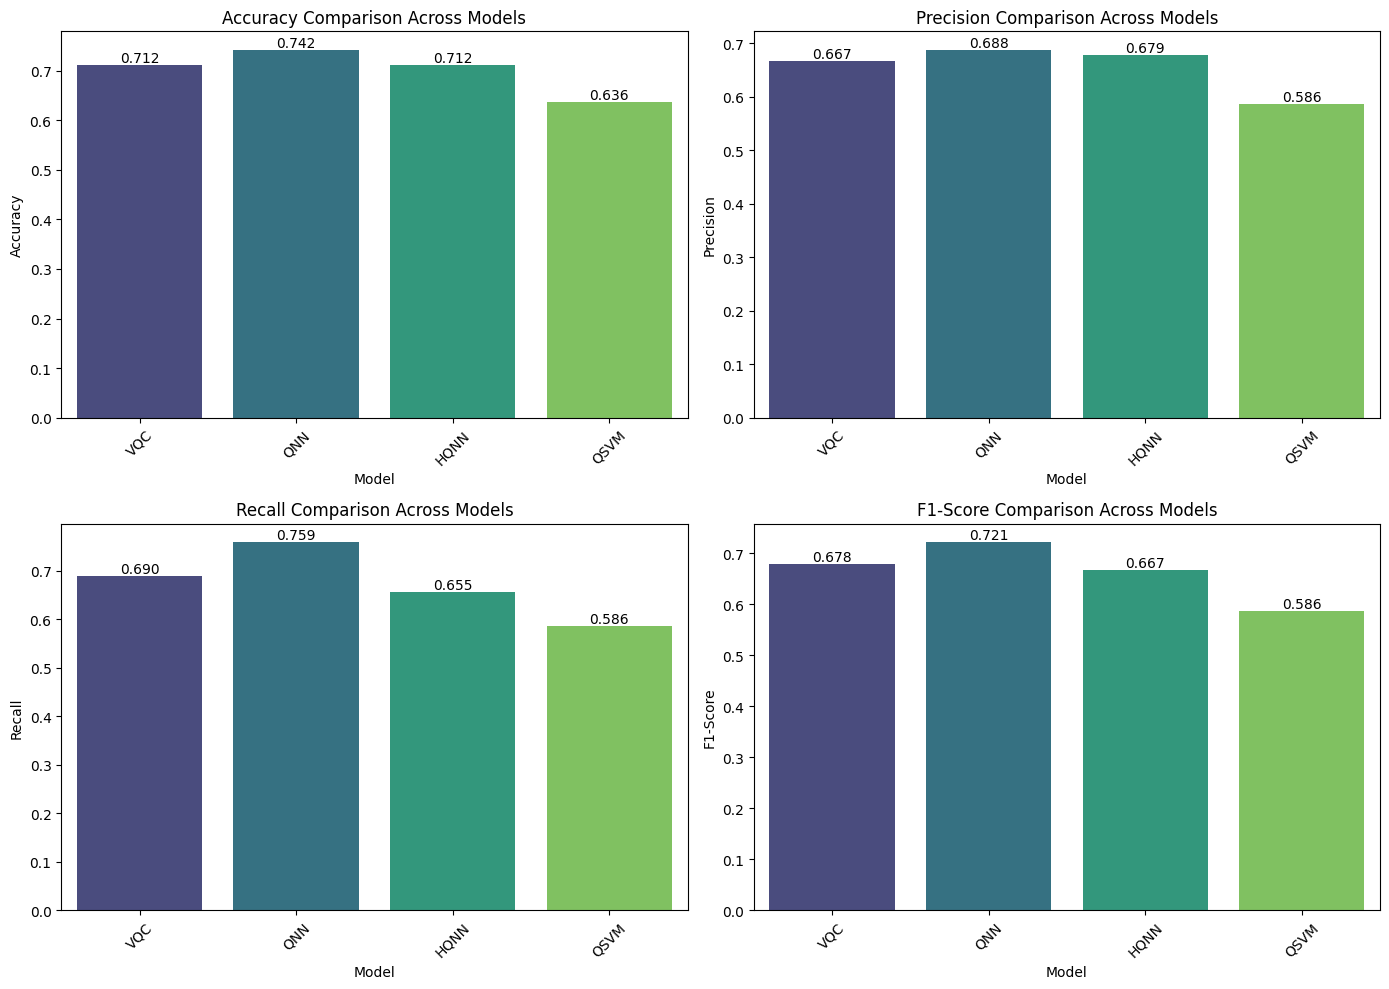

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
df_plot = df_results[metrics_to_plot]

# Create subplots for each metric
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(x=df_plot.index, y=metric, data=df_plot, ax=axes[i], palette='viridis', hue=df_plot.index, legend=False)
    axes[i].set_title(f'{metric} Comparison Across Models')
    axes[i].set_ylabel(metric)
    axes[i].set_xlabel('Model')
    axes[i].tick_params(axis='x', rotation=45)
    # Add value labels on top of bars
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.3f')

plt.tight_layout()
plt.show()

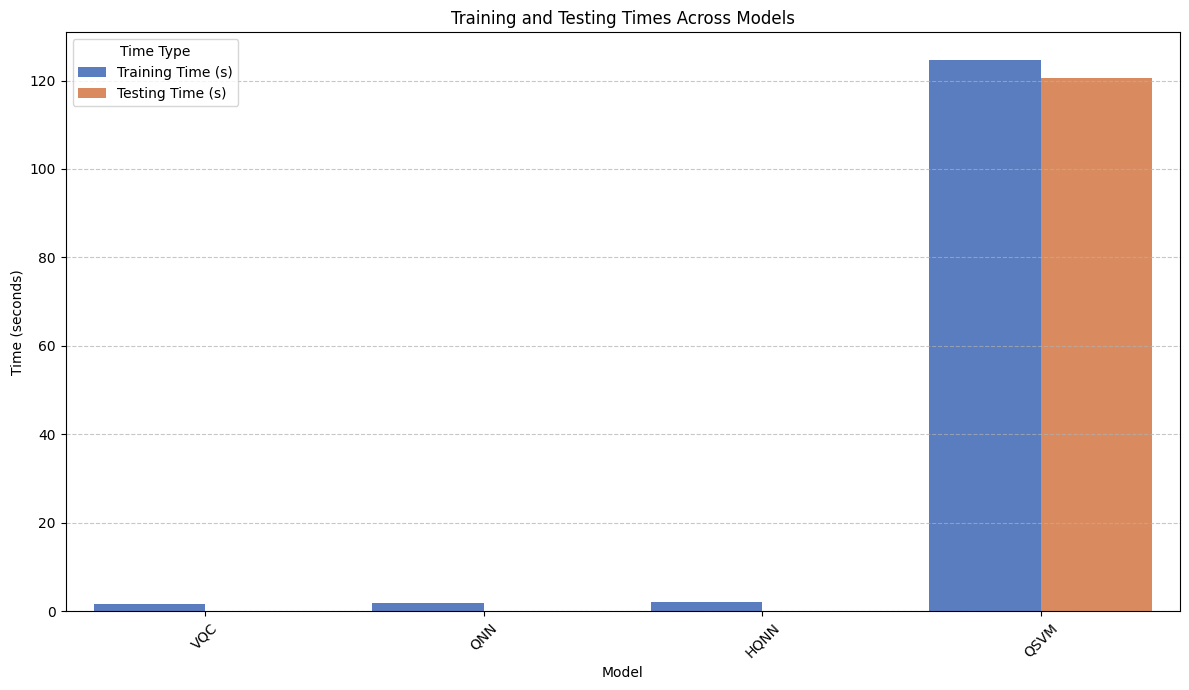

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for plotting training and testing times
time_metrics = ['Training Time (s)', 'Testing Time (s)']
df_time_plot = df_results[time_metrics].reset_index()
df_time_plot = df_time_plot.rename(columns={'index': 'Model'})

# Melt the DataFrame to long format for easier plotting with seaborn
df_time_melted = df_time_plot.melt(id_vars='Model', var_name='Time Type', value_name='Time (s)')

# Create the bar plot
fig = plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Time (s)', hue='Time Type', data=df_time_melted, palette='muted')
plt.title('Training and Testing Times Across Models')
plt.ylabel('Time (seconds)')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.legend(title='Time Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

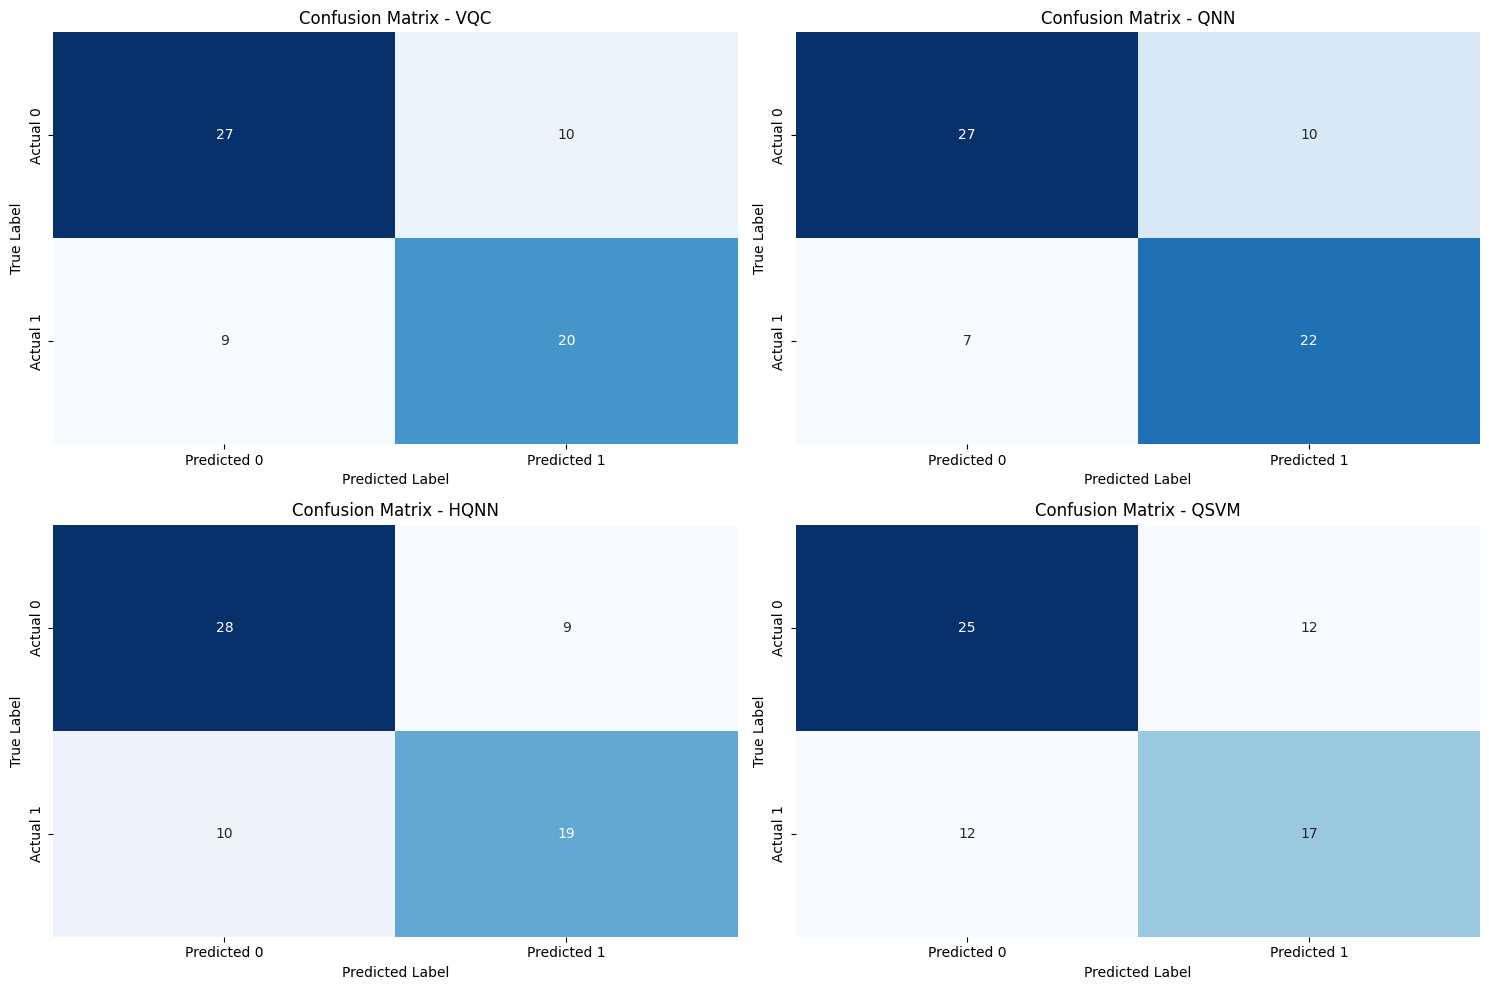

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming predictions_data contains 'y_test' and 'y_pred' for each model
# predictions_data = {'y_test': y_test, 'VQC': {'y_pred': y_pred_vqc, ...}, ...}

# Exclude 'Random Forest' from the models to plot
models_to_plot = [model_name for model_name in predictions_data.keys() if model_name != 'y_test' and model_name != 'Random Forest']

plt.figure(figsize=(15, 10))
# Adjust subplot grid based on number of models (now 4 instead of 5)
# Using 2 rows, 2 columns for 4 plots
subplot_rows = 2
subplot_cols = 2

for i, model_name in enumerate(models_to_plot):
    y_true = predictions_data['y_test']
    y_pred = predictions_data[model_name]['y_pred']

    cm = confusion_matrix(y_true, y_pred)

    plt.subplot(subplot_rows, subplot_cols, i + 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

plt.tight_layout()
plt.show()

### Additional Performance Metrics: Specificity, ROC-AUC, ROC Curve, and Precision-Recall Curve

Let's now compute and visualize 'Specificity' and 'ROC-AUC' scores for all models, and then plot their respective curves.

In [20]:
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, auc

# Calculate Specificity for all models and add to df_results
for model_name in predictions_data.keys():
    if model_name != 'y_test':
        y_true = predictions_data['y_test']
        y_pred = predictions_data[model_name]['y_pred']
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()

        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        df_results.loc[model_name, 'Specificity'] = specificity

# Calculate ROC-AUC for all models and add to df_results
for model_name in predictions_data.keys():
    if model_name != 'y_test':
        y_true = predictions_data['y_test']
        y_prob = predictions_data[model_name]['y_prob']

        # Ensure y_prob is valid for AUC calculation (not all zeros or ones if classes present)
        if len(np.unique(y_true)) > 1 and len(np.unique(y_prob)) > 1: # Check if there are at least two unique true labels and predicted probabilities
            roc_auc = roc_auc_score(y_true, y_prob)
            df_results.loc[model_name, 'ROC-AUC'] = roc_auc
        else:
            df_results.loc[model_name, 'ROC-AUC'] = np.nan # Assign NaN if ROC-AUC cannot be calculated


print("Updated Performance Metrics Comparison (including Specificity and ROC-AUC):")
print("="*80)
display(df_results.to_string())
print("="*80)

Updated Performance Metrics Comparison (including Specificity and ROC-AUC):


'               Accuracy  Precision    Recall  F1-Score  Training Time (s)  Testing Time (s)  Specificity   ROC-AUC\nVQC            0.712121   0.666667  0.689655  0.677966           1.588943          0.007271     0.729730  0.799627\nQNN            0.742424   0.687500  0.758621  0.721311           1.936680          0.009012     0.729730  0.811743\nHQNN           0.712121   0.678571  0.655172  0.666667           2.164706          0.007416     0.756757  0.830382\nQSVM           0.636364   0.586207  0.586207  0.586207         124.666825        120.552958     0.675676  0.694781\nRandom Forest  0.787879   0.857143  0.620690  0.720000           0.769947          0.023217     0.918919  0.899348'

### Model Comparison: All Classification Metrics

Here's an updated bar plot comparing all classification metrics (Accuracy, Precision, Recall, F1-Score, Specificity, and ROC-AUC) across all models.

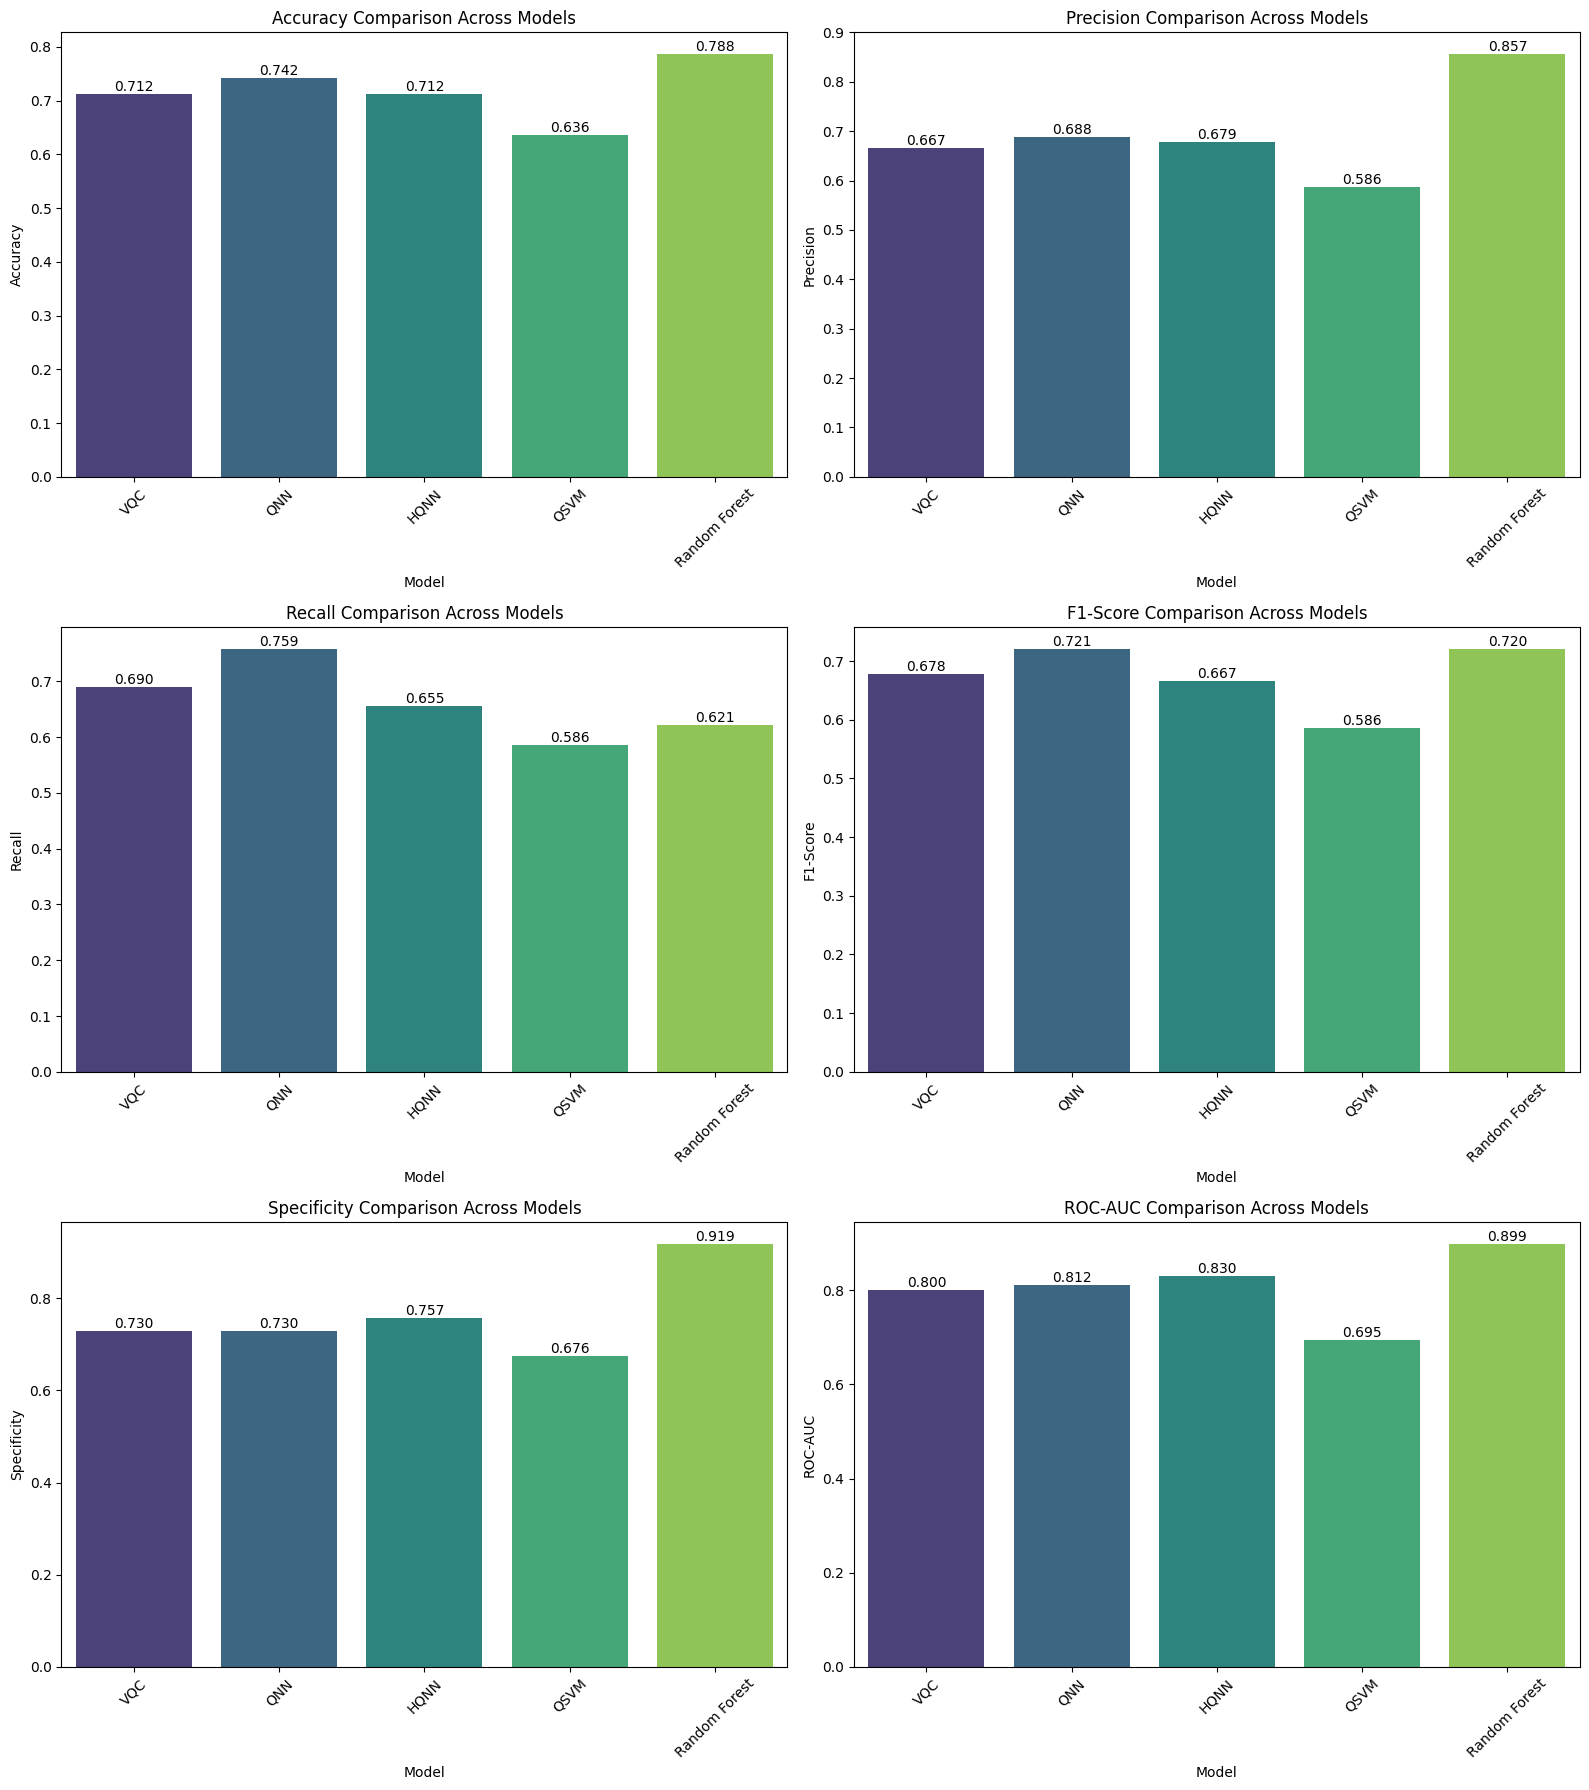

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
metrics_to_plot_all = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Specificity', 'ROC-AUC']
df_plot_all = df_results[metrics_to_plot_all]

# Create subplots for each metric
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot_all):
    # Filter out NaN values if any (e.g., for ROC-AUC if not calculable)
    plot_data = df_plot_all[metric].dropna()
    if not plot_data.empty:
        sns.barplot(x=plot_data.index, y=metric, data=plot_data.reset_index(), ax=axes[i], palette='viridis', hue='index', legend=False)
        axes[i].set_title(f'{metric} Comparison Across Models')
        axes[i].set_ylabel(metric)
        axes[i].set_xlabel('Model')
        axes[i].tick_params(axis='x', rotation=45)
        # Add value labels on top of bars
        for container in axes[i].containers:
            axes[i].bar_label(container, fmt='%.3f')
    else:
        axes[i].set_title(f'{metric} (No Data)')
        axes[i].set_visible(False) # Hide empty subplots

plt.tight_layout()
plt.show()

### ROC Curves for All Models

The Receiver Operating Characteristic (ROC) curve is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. The Area Under the Curve (AUC) is a measure of the overall performance of a classifier.

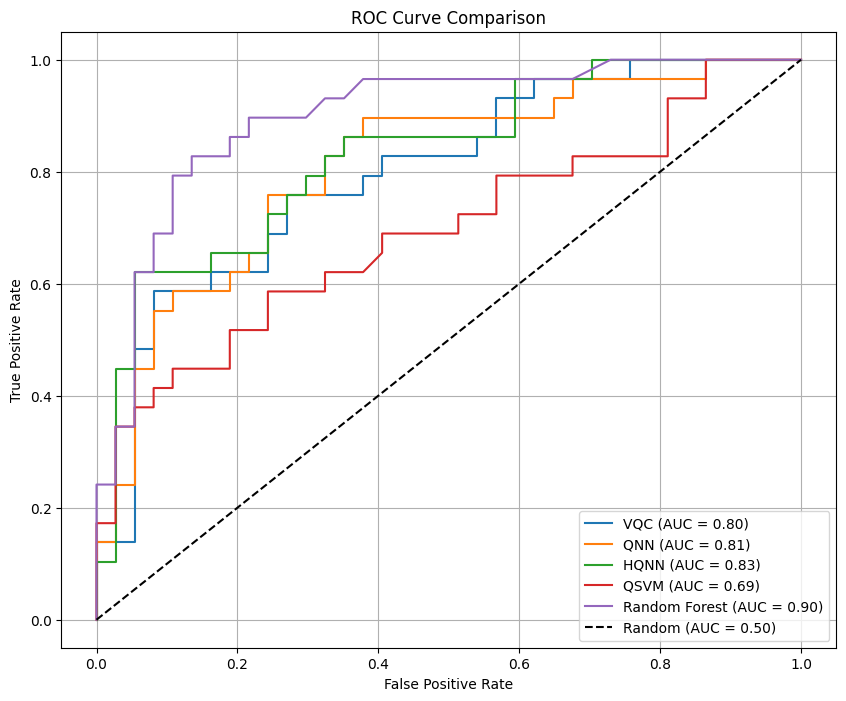

In [22]:
plt.figure(figsize=(10, 8))

y_true = predictions_data['y_test']

for model_name in predictions_data.keys():
    if model_name != 'y_test':
        y_prob = predictions_data[model_name]['y_prob']

        # Check if ROC-AUC is calculable for this model
        if len(np.unique(y_true)) > 1 and len(np.unique(y_prob)) > 1:
            fpr, tpr, _ = roc_curve(y_true, y_prob)
            roc_auc = roc_auc_score(y_true, y_prob)
            plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
        else:
            print(f"Skipping ROC Curve for {model_name}: Not enough unique classes or probability scores.")

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Precision-Recall Curves for All Models

The Precision-Recall curve shows the trade-off between precision and recall for different thresholds. This curve is particularly useful for imbalanced datasets where the positive class is rare.

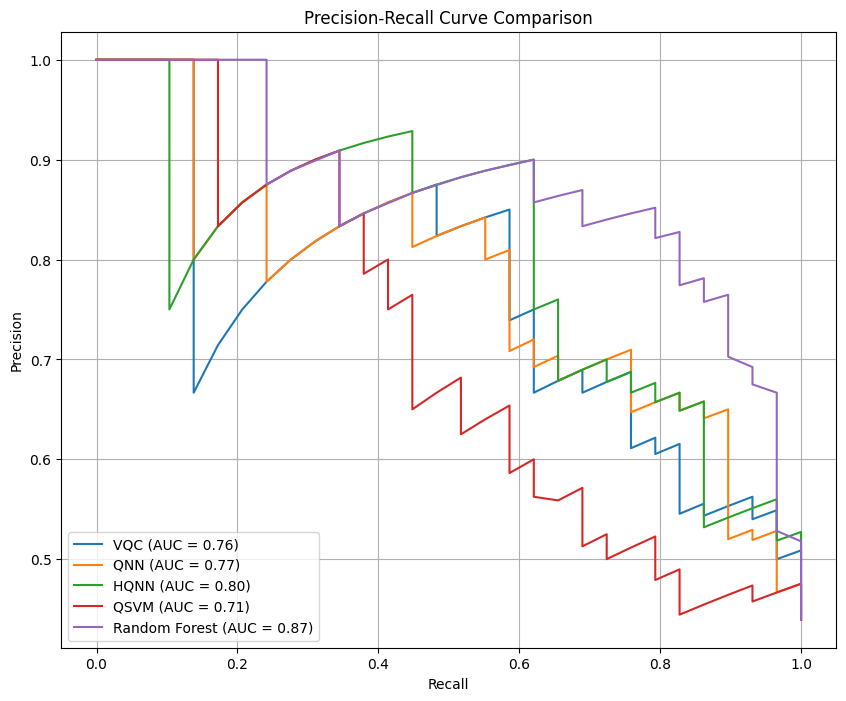

In [23]:
plt.figure(figsize=(10, 8))

y_true = predictions_data['y_test']

for model_name in predictions_data.keys():
    if model_name != 'y_test':
        y_prob = predictions_data[model_name]['y_prob']

        # Check if Precision-Recall AUC is calculable for this model
        if len(np.unique(y_true)) > 1 and len(np.unique(y_prob)) > 1:
            precision, recall, _ = precision_recall_curve(y_true, y_prob)
            pr_auc = auc(recall, precision)
            plt.plot(recall, precision, label=f'{model_name} (AUC = {pr_auc:.2f})')
        else:
            print(f"Skipping Precision-Recall Curve for {model_name}: Not enough unique classes or probability scores.")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

### Feature Importance for Random Forest Model

Feature importance indicates how much each feature contributes to the prediction of the Random Forest model. We will train a new Random Forest Classifier to extract and visualize these importances.

In [24]:
from sklearn.ensemble import RandomForestClassifier

# Retrain Random Forest to extract feature importances
# Reuse the preprocessed data (X_train, y_train, X_test, y_test) from load_and_preprocess_data()

rf_model_for_importance = RandomForestClassifier(random_state=42)
rf_model_for_importance.fit(X_train, y_train)

# Get feature importances
feature_importances = rf_model_for_importance.feature_importances_

# Get feature names (assuming the same order as in load_and_preprocess_data)
feature_names = ['Age', 'Cholesterol', 'Maximum Heart Rate', 'Resting Blood Pressure']

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

display(importance_df)

,Feature,Importance
2,Maximum Heart Rate,0.359702
0,Age,0.248533
1,Cholesterol,0.208694
3,Resting Blood Pressure,0.183071


/tmp/ipykernel_448/2407177291.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


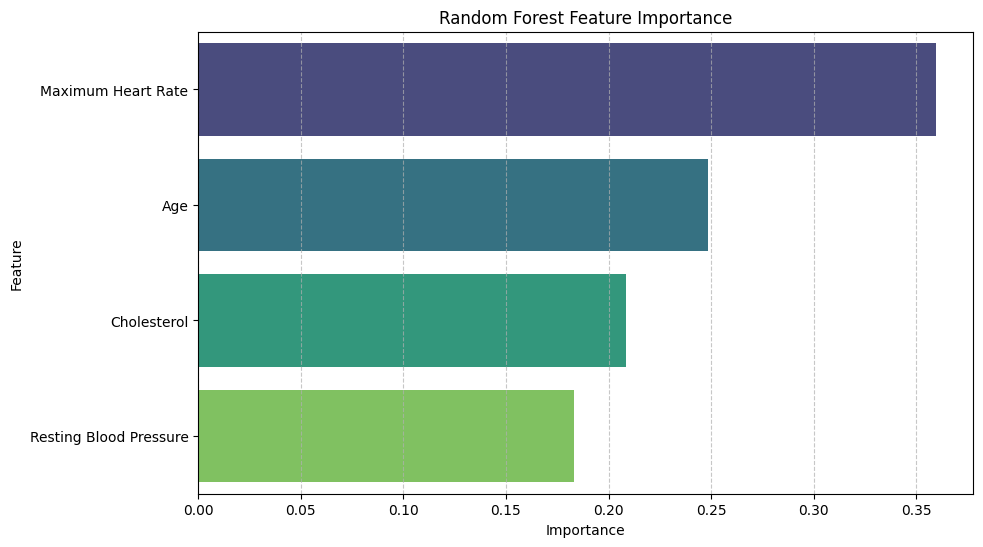

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()